# 03 — Surface classification

Combines lidar, land cover, and building footprints into the obstruction classes used by the horizon analysis.


In [1]:
# Load the surface-classification modules, define data directories, and read the observer inputs.
import json

import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import rasterio
from matplotlib.colors import BoundaryNorm, ListedColormap

from eclipse_viewshed.project import repository_root
PROJECT_ROOT = repository_root()

from eclipse_viewshed import aoi, landcover, surface, vector

RAW = PROJECT_ROOT / "data" / "raw"
INTERIM = PROJECT_ROOT / "data" / "interim"
PROCESSED = PROJECT_ROOT / "data" / "processed"
EXTERNAL = PROJECT_ROOT / "data" / "external"
FIGURES = PROJECT_ROOT / "reports" / "figures"
WORLD_COVER = RAW / "worldcover"
GRB = RAW / "grb"
for d in (WORLD_COVER, GRB, INTERIM, PROCESSED, FIGURES):
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 110

DSM_VRT = INTERIM / "dsm_1m.vrt"
DTM_VRT = INTERIM / "dtm_1m.vrt"
for p in (DSM_VRT, DTM_VRT):
    if not p.exists():
        raise FileNotFoundError(f"{p} missing - run notebook 02 first")

observers = pd.read_csv(EXTERNAL / "observers.csv")
observers[["x_l72", "y_l72"]] = observers.apply(
    lambda r: pd.Series(aoi.to_lambert72(r["lat"], r["lon"])), axis=1)
primary = observers.iloc[0]
px, py = primary["x_l72"], primary["y_l72"]


## Height above terrain


In [2]:
# Calculate height above bare terrain by subtracting the DTM from the DSM.
NDSM = INTERIM / "ndsm_1m.tif"

# Rebuild when the elevation grid changes.
if surface.is_stale(NDSM, DSM_VRT):
    surface.compute_ndsm(DSM_VRT, DTM_VRT, NDSM)
    print(f"{NDSM.name}: built")
else:
    print(f"{NDSM.name}: cached and current")

with rasterio.open(NDSM) as src:
    print(f"  {src.width} x {src.height} px, {src.dtypes[0]}, "
          f"nodata {src.nodata}, driver {src.driver}")
    print(f"  size on disk: {NDSM.stat().st_size/1e6:.0f} MB")


ndsm_1m.tif: cached and current
  16000 x 11000 px, float32, nodata -9999.0, driver GTiff
  size on disk: 276 MB


## Water mask


In [3]:
# Download WorldCover, align it to the lidar grid, and derive the water mask.
LANDCOVER = WORLD_COVER / "worldcover_10m.tif"
WATER = INTERIM / "water_mask.tif"

# Reproject categorical land cover with nearest-neighbour resampling.
lc_stale = surface.is_stale(LANDCOVER, NDSM)
landcover.fetch_landcover(NDSM, LANDCOVER, overwrite=lc_stale)
landcover.water_mask(LANDCOVER, WATER)
print(f"{LANDCOVER.name}: {'rebuilt' if lc_stale else 'cached and current'}")

counts_lc = landcover.class_counts(LANDCOVER)
total_lc = sum(counts_lc.values())
pd.DataFrame([
    {"code": k, "class": landcover.CLASSES.get(k, "unlisted"),
     "pixels": v, "share": f"{100*v/total_lc:.1f}%"}
    for k, v in sorted(counts_lc.items(), key=lambda kv: -kv[1])
])


  worldcover_10m.tif: from cache
worldcover_10m.tif: cached and current


,code,class,pixels,share
0,50,built-up,76357895,43.4%
1,30,grassland,30242035,17.2%
2,10,tree cover,27901124,15.9%
3,80,permanent water bodies,24552044,14.0%
4,40,cropland,15460376,8.8%
5,60,bare / sparse vegetation,957764,0.5%
6,90,herbaceous wetland,520935,0.3%
7,20,shrubland,7827,0.0%


## Building footprints


In [4]:
# Download the GRB building footprints covering the classifier and map extents.
GRB_RADIUS_M = 3000
classify_bounds = aoi.Bounds(
    px - GRB_RADIUS_M, py - GRB_RADIUS_M,
    px + GRB_RADIUS_M, py + GRB_RADIUS_M,
)
map_bounds = aoi.map_frame(
    list(zip(observers["lat"], observers["lon"])),
    margin=aoi.DATA_MARGIN_M,
)
grb_bounds = aoi.Bounds(
    min(classify_bounds.xmin, map_bounds.xmin),
    min(classify_bounds.ymin, map_bounds.ymin),
    max(classify_bounds.xmax, map_bounds.xmax),
    max(classify_bounds.ymax, map_bounds.ymax),
)

BUILDINGS_JSON = GRB / vector.cache_name(vector.LAYER_BUILDINGS, grb_bounds)
buildings = vector.fetch_features(
    vector.LAYER_BUILDINGS,
    grb_bounds,
    out_path=BUILDINGS_JSON,
)
geoms = vector.geometries(buildings)
print(f"{len(geoms)} building footprints")


  GRB_GBG_x147013_155013_y207561_216564.geojson: from cache
92427 building footprints


## Classification


In [5]:
# Rasterize the building footprints and combine all inputs into obstruction classes.
BUILDING_MASK = INTERIM / "grb_building_mask.tif"
CLASSES = INTERIM / "classes_1m.tif"

surface.rasterize_footprints(geoms, NDSM, BUILDING_MASK)
surface.classify(NDSM, BUILDING_MASK, CLASSES, water_path=WATER,
                 coverage_bounds=grb_bounds)

counts = surface.class_summary(CLASSES)
total = sum(counts.values())
rows = [{"class": surface.CLASS_LABELS.get(k, f"? {k}"),
         "pixels": v, "share": f"{100*v/total:.1f}%",
         "km2": round(v / 1e6, 2)}
        for k, v in sorted(counts.items())]
pd.DataFrame(rows)


,class,pixels,share,km2
0,nodata,25000000,14.2%,25.00
1,ground,94099038,53.5%,94.10
2,water,22042751,12.5%,22.04
3,vegetation,8838447,5.0%,8.84
4,building,12562837,7.1%,12.56
5,"tall, unattributed",13456927,7.6%,13.46


## Spatial check


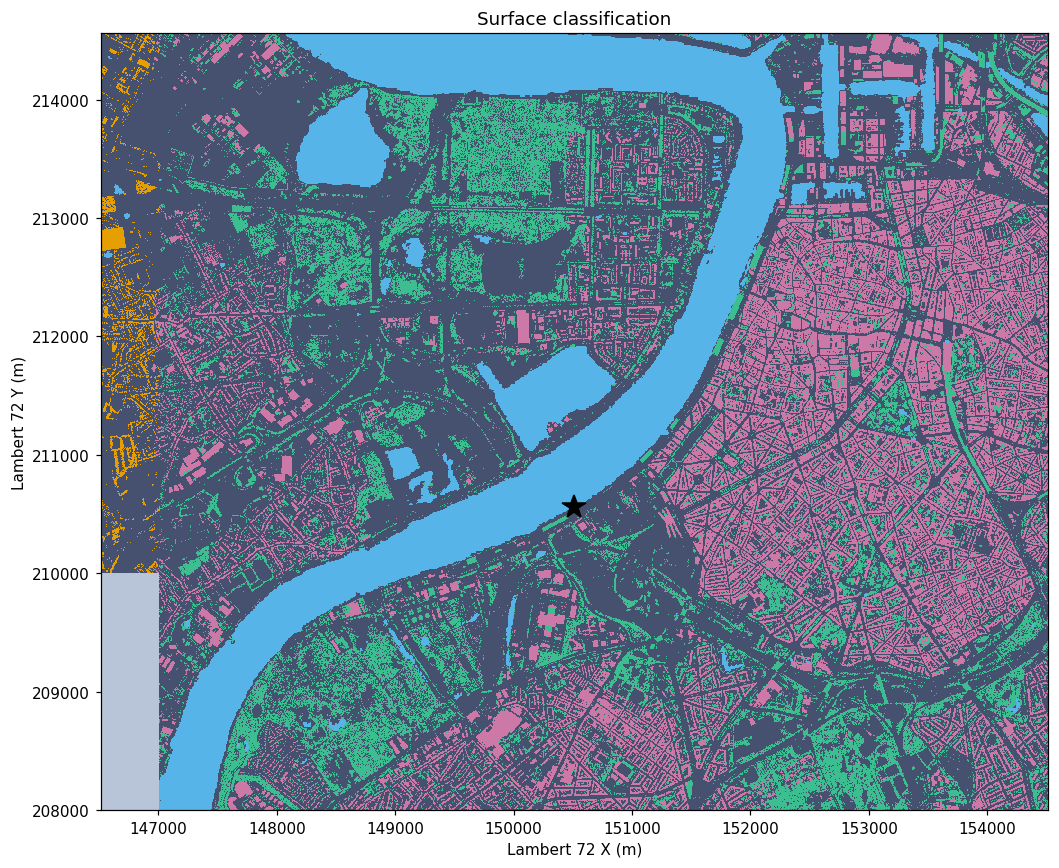

In [6]:
# Render the classified surface around the primary observer for a spatial check.
BOX_M, DEC = 4000, 4
with rasterio.open(CLASSES) as src:
    bounds = src.bounds
    x0, x1 = max(px - BOX_M, bounds.left), min(px + BOX_M, bounds.right)
    y0, y1 = max(py - BOX_M, bounds.bottom), min(py + BOX_M, bounds.top)
    win = rasterio.windows.from_bounds(x0, y0, x1, y1, src.transform)
    cls = src.read(
        1,
        window=win,
        out_shape=(int(win.height) // DEC, int(win.width) // DEC),
    )

codes = [
    surface.CLASS_NODATA,
    surface.CLASS_GROUND,
    surface.CLASS_WATER,
    surface.CLASS_VEGETATION,
    surface.CLASS_BUILDING,
    surface.CLASS_UNKNOWN,
]
cmap = ListedColormap([surface.CLASS_COLOURS[c] for c in codes])
norm = BoundaryNorm([c - 0.5 for c in codes] + [codes[-1] + 0.5], cmap.N)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(
    cls,
    cmap=cmap,
    norm=norm,
    extent=[x0, x1, y0, y1],
    origin="upper",
    interpolation="nearest",
)
ax.plot(px, py, "k*", ms=16)
ax.set_xlabel("Lambert 72 X (m)")
ax.set_ylabel("Lambert 72 Y (m)")
ax.set_title("Surface classification")
fig.tight_layout()
fig.savefig(FIGURES / "03_classification.png", dpi=150)
plt.show()


## Output summary


In [7]:
# Save a compact summary of the classified surface and its source coverage.
summary = {
    "primary_observer": primary["name"],
    "grb_radius_m": GRB_RADIUS_M,
    "grb_footprints": len(geoms),
    "class_pixels": {
        surface.CLASS_LABELS.get(k, str(k)): int(v)
        for k, v in sorted(counts.items())
    },
}
out = PROCESSED / "03_surface_summary.json"
out.write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))


{
  "primary_observer": "Nieuw Zuid",
  "grb_radius_m": 3000,
  "grb_footprints": 92427,
  "class_pixels": {
    "nodata": 25000000,
    "ground": 94099038,
    "water": 22042751,
    "vegetation": 8838447,
    "building": 12562837,
    "tall, unattributed": 13456927
  }
}
